# Projeto - Engine de Xadrez
### Daniel Couto

Este projeto pretende desenvolver, testar e comparar diferentes arquiteturas e heurísticas para uma rede neural jogar xadrez. Usarei o dataset https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations?resource=download  

**Objetivos.**
- construir uma engine que avalie e sugira o melhor lance;
- comparar arquiteturas simples e profundas;
- investigar o efeito de escolhas de treinamento;
- analisar erros e limitações do modelo;
- contruir uma rede para explicar o porquê do lance.

**Métodos gerais.**
- Usarei a biblioteca python-chess para tratar com mais domínio dos dados.
- Registre as escolhas principais de hiperparâmetros.
- Quando o enunciado pedir comparação, use evidências dos seus resultados.
- Não apague as células do enunciado.
- Use o conjunto de **teste** apenas na etapa final.



### Configurações inicias

In [2]:
import chess
import random
import numpy as np
from pathlib import Path
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch.optim as optim
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


seed = 1981
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "DCP"
output_dir = Path("assignment1_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

Semente: 1981
Dispositivo: cuda
Versão do Torch: 2.11.0+cu128
Versão do Torchvision: 0.26.0+cu128
Diretório de saída: assignment1_outputs/DCP


/home/al.daniel.pereira/Downloads/git_curso/ml2_trabalhos_2026/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Modelo de Avaliação - Engine

Aqui vou construir um modelo capaz de avaliar uma posição de xadrez, e userei uma MCTS para a escolha de melhor lance. Treinarei o modelo em um dataset com posições de xadrez e a correspondente avaliação em centipawns pelo StockFish.

### 1. Importação da Dataset e Análise Exploratória

In [4]:
df = pd.read_csv('chessData.csv')
print(df.head())
print(f"Tamanho do dataset: {len(df):.2f}")

                                                 FEN Evaluation
0  rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...        -10
1  rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...        +56
2  rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...         -9
3  rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...        +52
4  rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...        -26
Tamanho do dataset: 12958035.00


#### 1.1 Coluna 'Evaluation'

Para tirar informação da coluna de avaliação, como média e desvio padrão, primeiro precisamos transformá-la em float e também tirar as avaliações que "anuciam mate" no formato '#3' , por exemplo, pois ficaria intratável na análise. 

In [5]:
df['Evaluation_clean'] = df['Evaluation'].str.replace('+', '', regex=False)

df = df[~df['Evaluation_clean'].str.contains('#')]

df['Evaluation_clean'] = df['Evaluation_clean'].astype(float)

media_eval = df['Evaluation_clean'].mean()
std_eval = df['Evaluation_clean'].std()

print(f"Estatísticas da Avaliação (Centipawns)")
print(f"Média: {media_eval:.2f}")
print(f"Desvio Padrão: {std_eval:.2f}")
print(f"Total de posições sem mate próximo analisadas: {len(df['Evaluation_clean'])}")

Estatísticas da Avaliação (Centipawns)
Média: 45.51
Desvio Padrão: 813.89
Total de posições sem mate próximo analisadas: 12767881


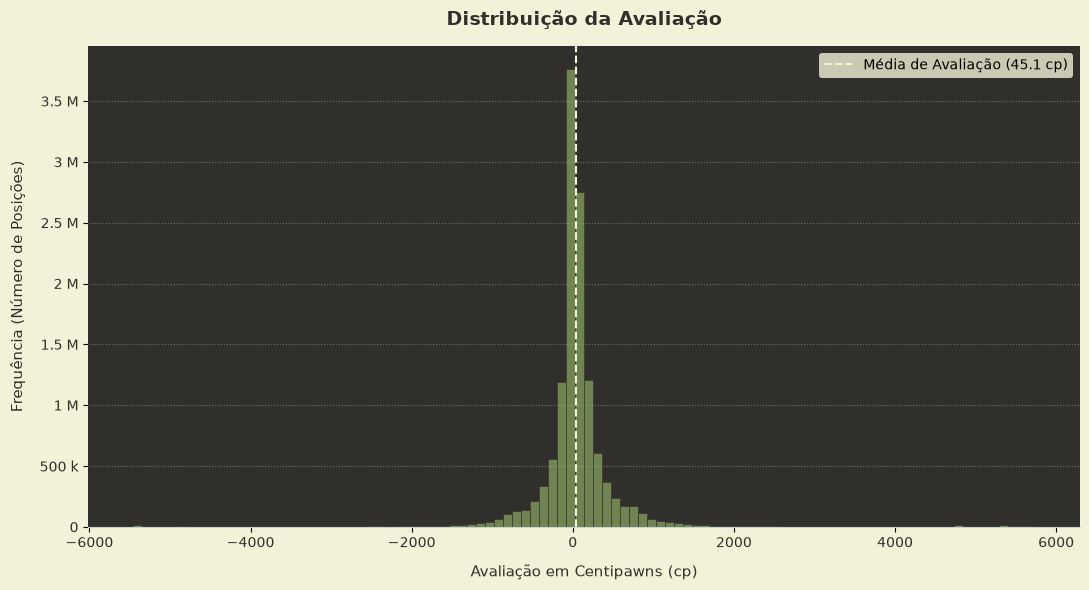

In [6]:
q_low = df['Evaluation_clean'].quantile(0.005)
q_high = df['Evaluation_clean'].quantile(0.995)
df_filtrado = df[(df['Evaluation_clean'] >= q_low) & (df['Evaluation_clean'] <= q_high)]

fig, ax = plt.subplots(figsize=(11, 6))
                                
COR_FUNDO_EXTERNO = '#F1F2D8' 
COR_FUNDO_INTERNO = '#312F2B' 

fig.patch.set_facecolor(COR_FUNDO_EXTERNO) 
ax.set_facecolor(COR_FUNDO_INTERNO)        

n, bins, patches = ax.hist(
    df_filtrado['Evaluation_clean'], 
    bins=100, 
    edgecolor=COR_FUNDO_INTERNO, 
    linewidth=0.5,
    alpha=0.85, 
    color='#7B9459'
)

media_eval = df_filtrado['Evaluation_clean'].mean()

ax.axvline(
    media_eval, 
    color='#F1F2D8', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Média de Avaliação ({media_eval:.1f} cp)' 
)

ax.set_title('Distribuição da Avaliação', fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_xlabel('Avaliação em Centipawns (cp)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylabel('Frequência (Número de Posições)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)

ax.xaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)

ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6') 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1') 

ax.legend(frameon=True, facecolor='#F1F2D8', edgecolor='none', fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

Para melhorar a visualização, filtrei para eliminar os 0,5% menores avaliações e as 0,55 maiores avaliações.

#### 1.2 Coluna 'FEN'

Para analisarmos a coluna 'FEN' com as posições, podemos começar explorando as estatísticas sobre a quantidade de peças. Isso pode ser importante para sabermos se o dataset tem algum viés de posições mais de abertura, meio jogo ou finais.

In [7]:
def contar_pecas(fen):
    board = chess.Board(fen)
    return len(board.piece_map())

df['Quantidade_Pecas'] = df['FEN'].apply(contar_pecas)

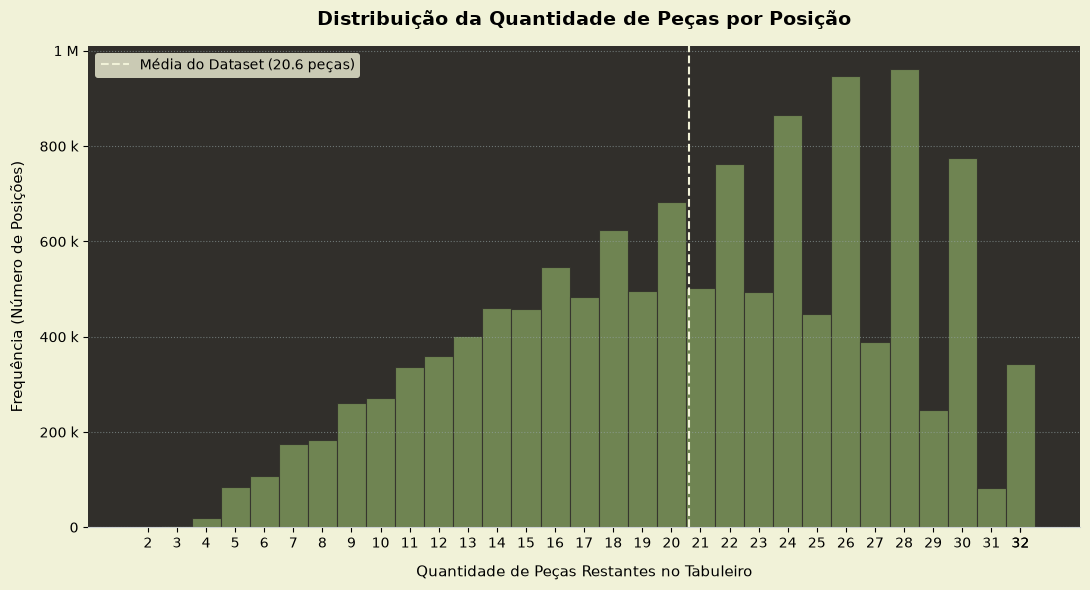

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))

COR_FUNDO_EXTERNO = '#F1F2D8' 
COR_FUNDO_INTERNO = '#312F2B' 

fig.patch.set_facecolor(COR_FUNDO_EXTERNO) 
ax.set_facecolor(COR_FUNDO_INTERNO)        

n, bins, patches = ax.hist(
    df['Quantidade_Pecas'], 
    bins=range(2, 34), 
    edgecolor=COR_FUNDO_INTERNO, 
    linewidth=0.8,
    alpha=0.85, 
    color='#7B9459',           
    align='left'
)

media_pecas = df['Quantidade_Pecas'].mean()

ax.axvline(
    media_pecas, 
    color='#F1F2D8', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Média do Dataset ({media_pecas:.1f} peças)' 
)

ax.legend(frameon=True, facecolor='#F1F2D8', edgecolor='none', fontsize=10)

ax.set_title('Distribuição da Quantidade de Peças por Posição', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quantidade de Peças Restantes no Tabuleiro', fontsize=11, labelpad=10)
ax.set_ylabel('Frequência (Número de Posições)', fontsize=11, labelpad=10)

ax.set_xticks(list(range(2, 33, 1)) + [32])
ax.xaxis.set_tick_params(labelsize=10)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
ax.yaxis.set_tick_params(labelsize=10)

ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6') 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1') 

ax.legend(frameon=True, facecolor='#F1F2D8', edgecolor='none', fontsize=10)

plt.tight_layout()
plt.show()

O histograma mostra uma distribuição bem aceitável de quantidade de peças, mas o que salta de informação é a disparidade de posições com quantidade de peças pares, o que faz bastante sentido e até condiz com a realidade de um jogo, no início é comum que os adversários estejam com a mesma quantidade de peças.

#### 1.3 Split 

In [9]:
df_train, df_temp = train_test_split(df, test_size=0.20, random_state=seed)

df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=seed)

print(f"Quantidade de exemplos em Treino:   {len(df_train)}")
print(f"Quantidade de exemplos em Validação: {len(df_val)}")
print(f"Quantidade de exemplos em Teste:     {len(df_test)}")

Quantidade de exemplos em Treino:   10214304
Quantidade de exemplos em Validação: 1276788
Quantidade de exemplos em Teste:     1276789


### 2. Modelos

#### 2.1 Tensorização

Para que a CNN receba mais informação, vamos transformar nosso FEN em um tensor de 15 canais: os primeiros 12 funcionam como um mapeamento binário (one-hot) da posição das peças ($8 \times 8$), divididos igualmente entre brancas e pretas, enquanto as últimas 3 camadas adicionam o contexto dinâmico do jogo, onde o canal 12 indica a vez de jogar e os canais 13 e 14 representam os direitos de roque das brancas e das pretas, respectivamente. Essa estrutura entrega o tabuleiro mastigado para a rede, permitindo que os filtros convolucionais foquem direto no aprendizado de conceitos estratégicos.

In [10]:
class Dataset_tensor(Dataset):
    def __init__(self, dataframe):
        self.fens = dataframe['FEN'].values
        self.evals = dataframe['Evaluation_clean'].values

    def __len__(self):
        return len(self.fens)

    def FEN_para_tensor(self, fen):
        board = chess.Board(fen)
        
        tensor = np.zeros((15, 8, 8), dtype=np.float32)
        
        piece_to_channel = {
            (chess.PAWN, chess.WHITE): 0,
            (chess.KNIGHT, chess.WHITE): 1,
            (chess.BISHOP, chess.WHITE): 2,
            (chess.ROOK, chess.WHITE): 3,
            (chess.QUEEN, chess.WHITE): 4,
            (chess.KING, chess.WHITE): 5,
            (chess.PAWN, chess.BLACK): 6,
            (chess.KNIGHT, chess.BLACK): 7,
            (chess.BISHOP, chess.BLACK): 8,
            (chess.ROOK, chess.BLACK): 9,
            (chess.QUEEN, chess.BLACK): 10,
            (chess.KING, chess.BLACK): 11
        }
        
        # 1. Preenche os canais de 0 a 11 com a localização das peças
        for square, piece in board.piece_map().items():
            row = 7 - (square // 8)
            col = square % 8
            channel = piece_to_channel[(piece.piece_type, piece.color)]
            tensor[channel, row, col] = 1.0

        # 2. Canal 12: Vez de jogar 
        if board.turn == chess.WHITE:
            tensor[12, :, :] = 1.0

        # 3. Canal 13: Direitos de roque das Brancas
        if board.has_kingside_castling_rights(chess.WHITE) or board.has_queenside_castling_rights(chess.WHITE):
            tensor[13, :, :] = 1.0

        # 4. Canal 14: Direitos de roque das Pretas
        if board.has_kingside_castling_rights(chess.BLACK) or board.has_queenside_castling_rights(chess.BLACK):
            tensor[14, :, :] = 1.0

        return torch.tensor(tensor)

    def __getitem__(self, idx):
        fen = self.fens[idx]
        y = torch.tensor(self.evals[idx], dtype=torch.float32)
        X = self.FEN_para_tensor(fen)
        return X, y

train_dataset = Dataset_tensor(df_train)
val_dataset = Dataset_tensor(df_val)

batch_size = 256 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Total de Batches em Treino: {len(train_loader)}")
print(f"Total de Batches em Validação: {len(val_loader)}")

Total de Batches em Treino: 39900
Total de Batches em Validação: 4988


#### 2.2 CNN (baseline)

In [11]:
class ChessEvalCNN(nn.Module):
    """
    Baseline: CNN simples para avaliação de posições de xadrez.

    Entrada: tensor (batch, 15, 8, 8) -- ver Dataset_tensor.FEN_para_tensor
    Saída:   tensor (batch,) com a avaliação estimada em centipawns

    Arquitetura: 3 blocos Conv2d -> BatchNorm -> ReLU (sem pooling, pois o
    tabuleiro já é pequeno -- 8x8 -- e queremos preservar resolução espacial
    até o final), seguidos de Flatten e uma cabeça densa (MLP) com 2 camadas
    lineares até a saída escalar.
    """
    def __init__(self, in_channels=15, conv_channels=(32, 64, 64), hidden_dim=128, dropout=0.2):
        super().__init__()

        c1, c2, c3 = conv_channels

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, c1, kernel_size=3, padding=1),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),

            nn.Conv2d(c1, c2, kernel_size=3, padding=1),
            nn.BatchNorm2d(c2),
            nn.ReLU(inplace=True),

            nn.Conv2d(c2, c3, kernel_size=3, padding=1),
            nn.BatchNorm2d(c3),
            nn.ReLU(inplace=True),
        )

        # Tabuleiro 8x8 é mantido (padding=1, stride=1) -> achatamos c3 * 8 * 8
        flattened_dim = c3 * 8 * 8

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.head(x)
        return x.squeeze(-1)  # (batch, 1) -> (batch,)


model = ChessEvalCNN(in_channels=15).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal de parâmetros treináveis: {n_params:,}")


ChessEvalCNN(
  (conv_block): Sequential(
    (0): Conv2d(15, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total de parâmetros treináveis: 584,641


#### 2.2.1 Treinamento


In [12]:
num_epochs = 30
learning_rate = 1e-3
weight_decay = 1e-5
patience = 5  # early stopping

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print(f"Épocas máximas: {num_epochs}")
print(f"Learning rate inicial: {learning_rate}")
print(f"Weight decay: {weight_decay}")
print(f"Paciência (early stopping): {patience}")
print(f"Loss: {criterion}")
print(f"Otimizador: {optimizer.__class__.__name__}")


Épocas máximas: 30
Learning rate inicial: 0.001
Weight decay: 1e-05
Paciência (early stopping): 5
Loss: MSELoss()
Otimizador: Adam


##### 2.2.2 Loop de Treino

Época 01/30 | Treino MSE: 432219.63 | Validação MSE: 400834.64 | LR: 1.0e-03


Época 02/30 | Treino MSE: 381774.66 | Validação MSE: 367753.49 | LR: 1.0e-03


Época 03/30 | Treino MSE: 364427.00 | Validação MSE: 362740.70 | LR: 1.0e-03


Época 04/30 | Treino MSE: 351733.39 | Validação MSE: 347362.30 | LR: 1.0e-03


Época 05/30 | Treino MSE: 341933.16 | Validação MSE: 344468.22 | LR: 1.0e-03


...

Época 26/30 | Treino MSE: 236752.41 | Validação MSE: 292057.60 | LR: 1.0e-03


Época 27/30 | Treino MSE: 234261.71 | Validação MSE: 287250.13 | LR: 1.0e-03


Época 28/30 | Treino MSE: 231713.99 | Validação MSE: 286915.49 | LR: 1.0e-03


Época 29/30 | Treino MSE: 228989.56 | Validação MSE: 286480.25 | LR: 1.0e-03


Época 30/30 | Treino MSE: 226656.86 | Validação MSE: 286246.93 | LR: 1.0e-03

Melhor Validação MSE: 286246.93
Modelo salvo em: assignment1_outputs/DCP/best_model_baseline_cnn.pt


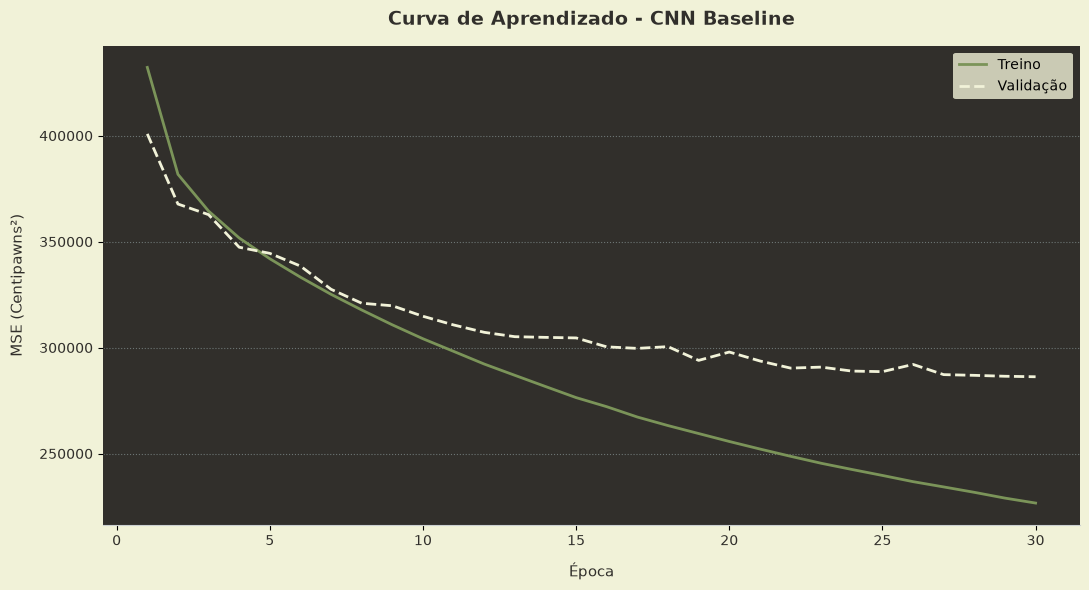

In [13]:
def run_epoch(model, loader, criterion, optimizer=None, device=device):
    """
    Roda uma época de treino (se optimizer for passado) ou de validação
    (se optimizer for None). Retorna a loss média (MSE) na época.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_samples = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for X, y in tqdm(loader, leave=False, desc="treino" if is_train else "validação"):
            X, y = X.to(device), y.to(device)

            if is_train:
                optimizer.zero_grad()

            preds = model(X)
            loss = criterion(preds, y)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X.size(0)
            total_samples += X.size(0)

    return total_loss / total_samples


train_losses = []
val_losses = []
best_val_loss = float("inf")
epochs_sem_melhora = 0
best_model_path = output_dir / student_run_tag / "best_model_baseline_cnn.pt"

for epoch in range(1, num_epochs + 1):
    train_loss = run_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = run_epoch(model, val_loader, criterion, optimizer=None, device=device)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Época {epoch:02d}/{num_epochs} | "
        f"Treino MSE: {train_loss:.2f} | "
        f"Validação MSE: {val_loss:.2f} | "
        f"LR: {current_lr:.1e}"
    )

    # Early stopping + checkpoint do melhor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_sem_melhora = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_sem_melhora += 1
        if epochs_sem_melhora >= patience:
            print(f"\nEarly stopping na época {epoch} (sem melhora por {patience} épocas).")
            break

print(f"\nMelhor Validação MSE: {best_val_loss:.2f}")
print(f"Modelo salvo em: {best_model_path}")

# Carrega o melhor checkpoint antes de seguir para análises/teste
model.load_state_dict(torch.load(best_model_path, map_location=device))

# Curva de treino x validação
fig, ax = plt.subplots(figsize=(11, 6))

COR_FUNDO_EXTERNO = '#F1F2D8'
COR_FUNDO_INTERNO = '#312F2B'

fig.patch.set_facecolor(COR_FUNDO_EXTERNO)
ax.set_facecolor(COR_FUNDO_INTERNO)

ax.plot(range(1, len(train_losses) + 1), train_losses, color='#7B9459', linewidth=2, label='Treino')
ax.plot(range(1, len(val_losses) + 1), val_losses, color='#F1F2D8', linewidth=2, linestyle='--', label='Validação')

ax.set_title('Curva de Aprendizado - CNN Baseline', fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_xlabel('Época', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylabel('MSE (Centipawns²)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)

ax.xaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)

ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1')

ax.legend(frameon=True, facecolor='#F1F2D8', edgecolor='none', fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()


### 3. Configuração da Árvore e Jogabilidade